📕 Começaremos importando as bibliotecas necessárias para o trabalho.

In [ ]:
# Importando as bibliotecas essenciais para Análise de Dados e ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Importando o módulo principal do Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

📘 Carregar base de dados (Inicio analise exploratoria)

Usaremos `google.colab import files` para importar o arquivo .csv

In [ ]:
from google.colab import files
import io

# 1. Solicita o upload do arquivo
uploaded = files.upload()

# 2. AUTOMATICAMENTE PEGA O NOME DO PRIMEIRO (E ÚNICO) ARQUIVO CARREGADO
file_name = list(uploaded.keys())[0]

# 3. Lê o arquivo CSV usando o Pandas
df = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))

# 4. Exibe as primeiras linhas para confirmar
print(f"Arquivo carregado com sucesso: {file_name}")
print(df.head())


Saving Atividade_Cap10_produtos_agricolas.csv to Atividade_Cap10_produtos_agricolas.csv
Arquivo carregado com sucesso: Atividade_Cap10_produtos_agricolas.csv
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


✅ Resumo Rapido, Tipos de valores, valores ausentes/nulos e se está balanceado.

In [ ]:
# Informações gerais sobre o dataset
print('\n=== INFORMAÇÕES DO DATASET ===')
print(f'Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas\n')
df.info()

# Verificar valores ausentes
print('\n=== VALORES AUSENTES ===')
missing = df.isnull().sum()
print(f'Total de valores ausentes: {missing.sum()}')
print(missing)

# Estatísticas descritivas das variáveis numéricas
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(2)

# Análise da variável target (label)
print('\n=== DISTRIBUIÇÃO DAS CULTURAS ===')
print(f'Número de culturas diferentes: {df["label"].nunique()}')
print(f'\nFrequência de cada cultura:')
print(df['label'].value_counts())



=== INFORMAÇÕES DO DATASET ===
Dimensões: 2200 linhas e 8 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

=== VALORES AUSENTES ===
Total de valores ausentes: 0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===

=== DISTRIBUIÇÃO DAS CULTURAS ===
Número de culturas diferentes: 22

Frequência de cada cultura:
label


📊 Começaremos a plotar os gráficos
> Inicio analise descritiva



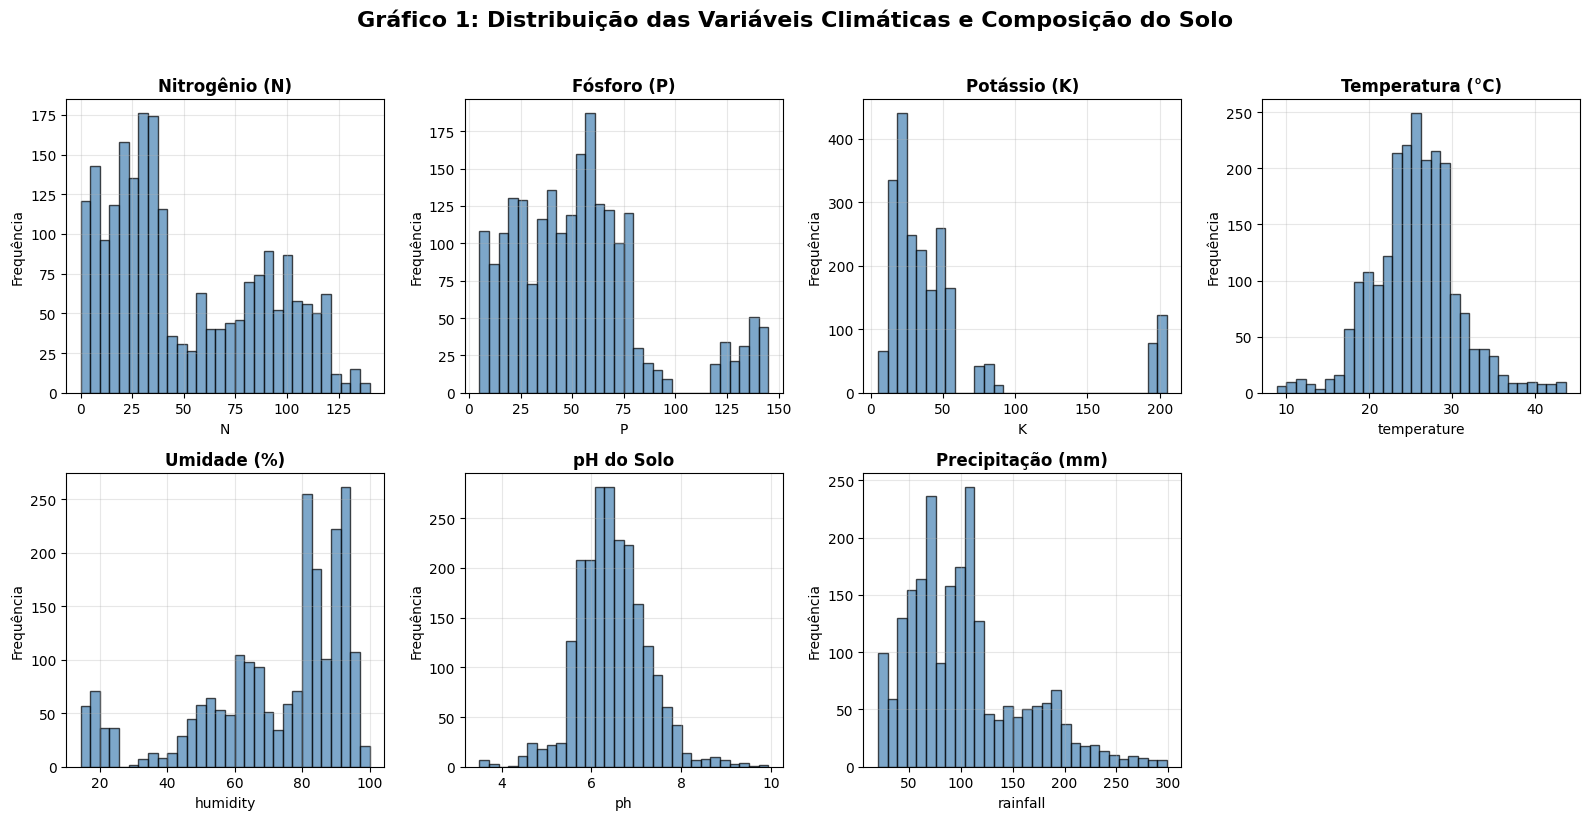


📊 ACHADOS DO GRÁFICO 1:
- Nitrogênio (N): Distribuição bimodal, indicando dois grupos de culturas com diferentes necessidades
- Fósforo (P) e Potássio (K): Ampla variação, sugerindo requisitos diversos entre culturas
- Temperatura: Concentração entre 20-30°C, típica de cultivos tropicais/subtropicais
- Umidade: Distribuição bimodal (culturas de baixa e alta umidade)
- pH: Principalmente entre 5-7 (ligeiramente ácido a neutro)
- Precipitação: Distribuição ampla, indicando culturas com diferentes necessidades hídricas


In [ ]:
# Gráfico 1: Distribuição das variáveis numéricas (Histogramas)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Gráfico 1: Distribuição das Variáveis Climáticas e Composição do Solo',
             fontsize=16, fontweight='bold', y=1.02)

variables = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
titles = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)', 'Temperatura (°C)',
          'Umidade (%)', 'pH do Solo', 'Precipitação (mm)']

for i, (var, title) in enumerate(zip(variables, titles)):
    row = i // 4
    col = i % 4
    axes[row, col].hist(df[var], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequência')
    axes[row, col].grid(True, alpha=0.3)

# Remover o último subplot (vazio)
fig.delaxes(axes[1, 3])

plt.tight_layout()
plt.show()

print('\n📊 ACHADOS DO GRÁFICO 1:')
print('- Nitrogênio (N): Distribuição bimodal, indicando dois grupos de culturas com diferentes necessidades')
print('- Fósforo (P) e Potássio (K): Ampla variação, sugerindo requisitos diversos entre culturas')
print('- Temperatura: Concentração entre 20-30°C, típica de cultivos tropicais/subtropicais')
print('- Umidade: Distribuição bimodal (culturas de baixa e alta umidade)')
print('- pH: Principalmente entre 5-7 (ligeiramente ácido a neutro)')
print('- Precipitação: Distribuição ampla, indicando culturas com diferentes necessidades hídricas')

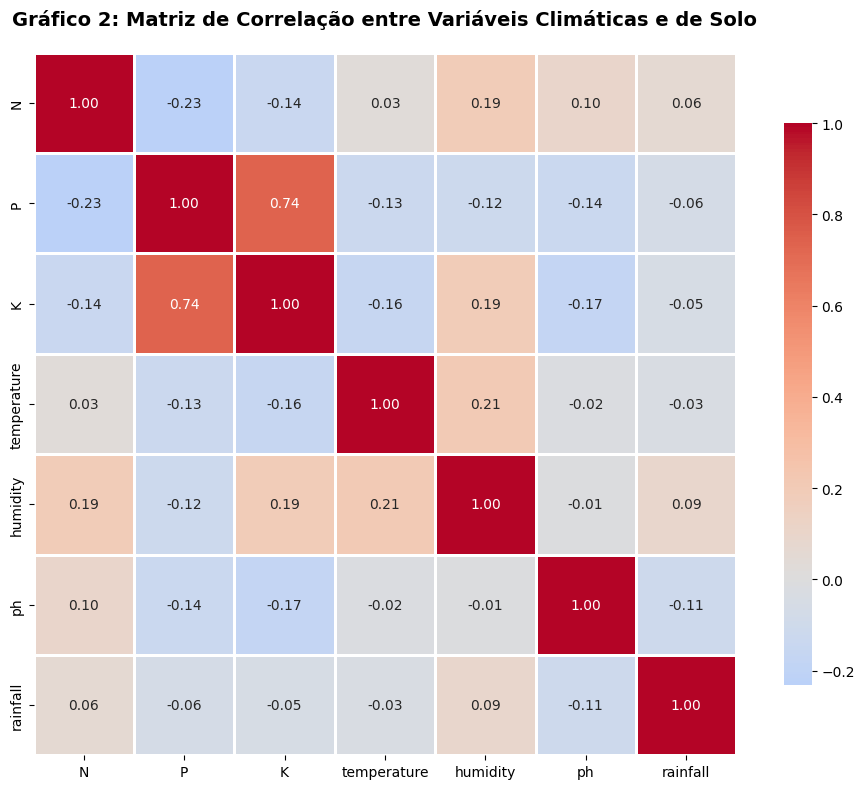


📊 ACHADOS DO GRÁFICO 2:
- Correlações geralmente fracas entre as variáveis (valores próximos de 0)
- Isso indica INDEPENDÊNCIA entre os fatores climáticos e de solo
- Importante para modelos preditivos: ausência de multicolinearidade
- Cada variável contribui com informação única para caracterizar as culturas


In [ ]:
# Gráfico 2: Matriz de Correlação
plt.figure(figsize=(10, 8))
correlation_matrix = df[variables].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Gráfico 2: Matriz de Correlação entre Variáveis Climáticas e de Solo',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n📊 ACHADOS DO GRÁFICO 2:')
print('- Correlações geralmente fracas entre as variáveis (valores próximos de 0)')
print('- Isso indica INDEPENDÊNCIA entre os fatores climáticos e de solo')
print('- Importante para modelos preditivos: ausência de multicolinearidade')
print('- Cada variável contribui com informação única para caracterizar as culturas')

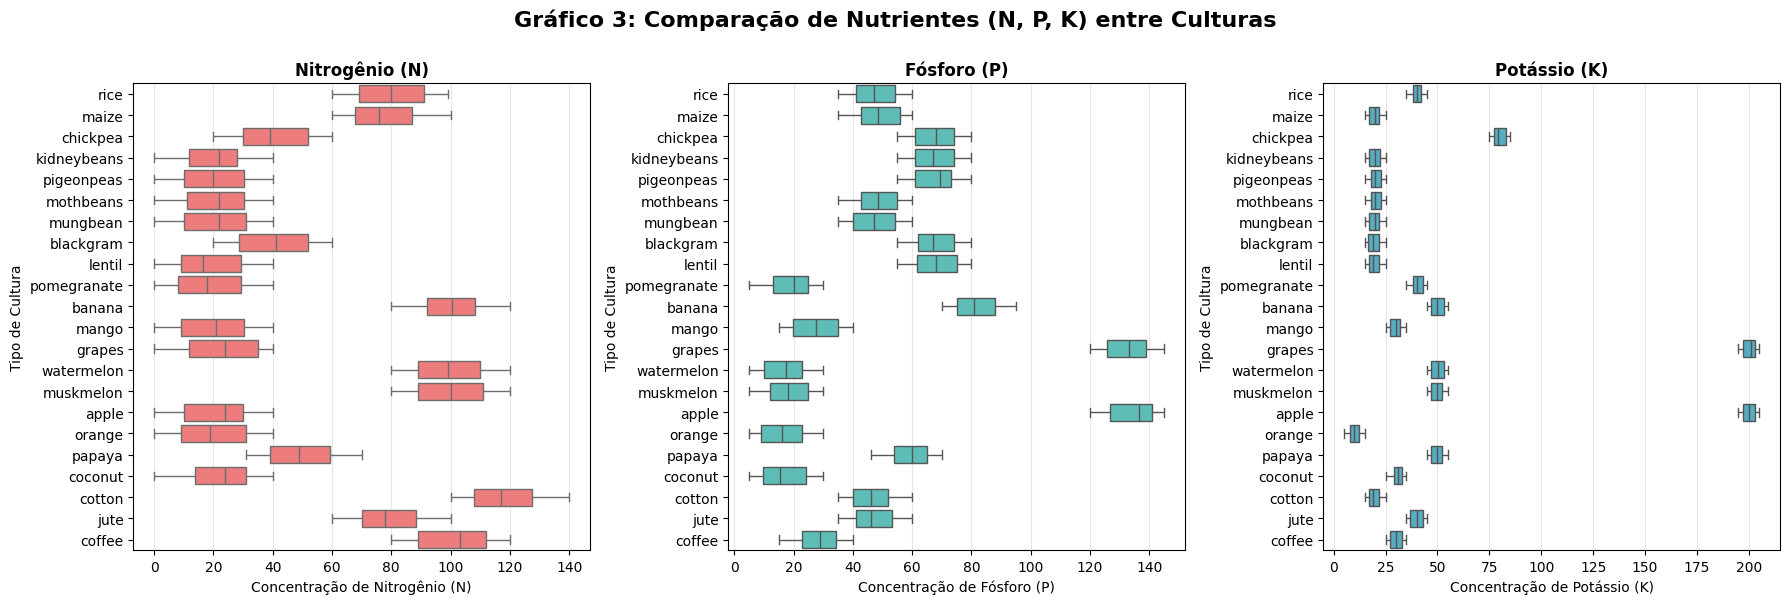


📊 ACHADOS DO GRÁFICO 3:
- NITROGÊNIO (N): Arroz, banana, algodão e juta requerem altos níveis; frutas como maçã e laranja requerem baixos níveis
- FÓSFORO (P): Maçã, banana e manga necessitam de altos níveis; laranja e leguminosas requerem baixos níveis
- POTÁSSIO (K): Maçã, banana e uva demandam muito potássio; grãos como arroz e milho precisam de níveis moderados
- Padrões distintos de NPK permitem diferenciar grupos de culturas (cereais, leguminosas, frutas)


In [ ]:
# Gráfico 3: Boxplot de Nutrientes por tipo de cultura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Gráfico 3: Comparação de Nutrientes (N, P, K) entre Culturas',
             fontsize=16, fontweight='bold', y=1.00)

nutrients = ['N', 'P', 'K']
nutrient_names = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (nutrient, name, color) in enumerate(zip(nutrients, nutrient_names, colors)):
    sns.boxplot(data=df, y='label', x=nutrient, ax=axes[i], color=color, orient='h')
    axes[i].set_title(name, fontweight='bold', fontsize=12)
    axes[i].set_xlabel(f'Concentração de {name}')
    axes[i].set_ylabel('Tipo de Cultura')
    axes[i].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n📊 ACHADOS DO GRÁFICO 3:')
print('- NITROGÊNIO (N): Arroz, banana, algodão e juta requerem altos níveis; frutas como maçã e laranja requerem baixos níveis')
print('- FÓSFORO (P): Maçã, banana e manga necessitam de altos níveis; laranja e leguminosas requerem baixos níveis')
print('- POTÁSSIO (K): Maçã, banana e uva demandam muito potássio; grãos como arroz e milho precisam de níveis moderados')
print('- Padrões distintos de NPK permitem diferenciar grupos de culturas (cereais, leguminosas, frutas)')

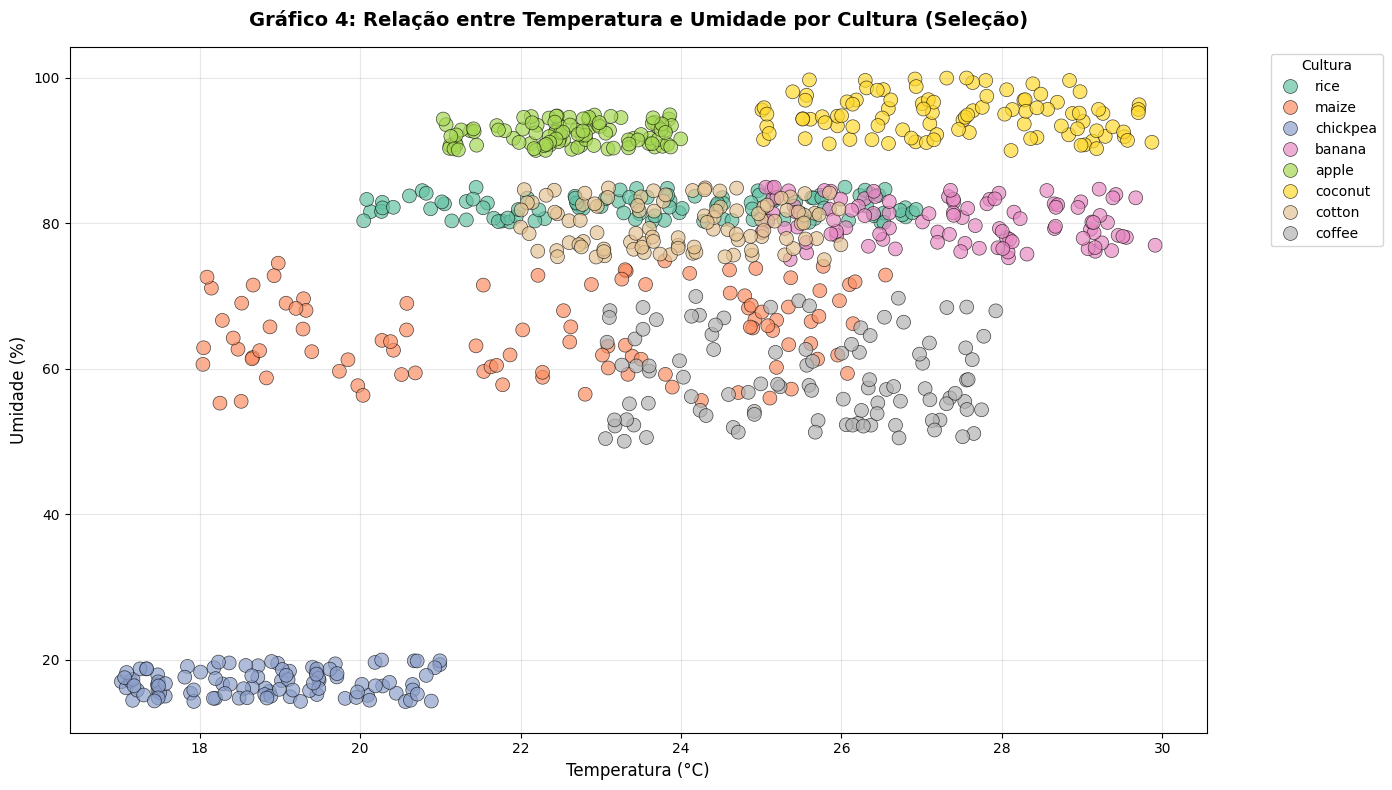


📊 ACHADOS DO GRÁFICO 4:
- ARROZ: Alta umidade (80-85%) e temperatura moderada (20-27°C) - cultivo em áreas alagadas
- MILHO: Umidade média-baixa (55-75%) e temperatura variada - cultura mais versátil
- GRÃO DE BICO: Baixa umidade (14-20%) e temperatura moderada - cultivo em climas secos
- MAÇÃ e BANANA: Alta umidade e temperatura específica - frutas tropicais/temperadas
- Clusters bem definidos indicam que temperatura e umidade são bons preditores de culturas


In [ ]:
# Gráfico 4: Scatter plot Temperatura vs Umidade
plt.figure(figsize=(14, 8))
crops_to_highlight = ['rice', 'maize', 'chickpea', 'apple', 'banana', 'cotton', 'coffee', 'coconut']
df_highlight = df[df['label'].isin(crops_to_highlight)]

sns.scatterplot(data=df_highlight, x='temperature', y='humidity', hue='label',
                s=100, alpha=0.7, palette='Set2', edgecolor='black', linewidth=0.5)
plt.title('Gráfico 4: Relação entre Temperatura e Umidade por Cultura (Seleção)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Temperatura (°C)', fontsize=12)
plt.ylabel('Umidade (%)', fontsize=12)
plt.legend(title='Cultura', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📊 ACHADOS DO GRÁFICO 4:')
print('- ARROZ: Alta umidade (80-85%) e temperatura moderada (20-27°C) - cultivo em áreas alagadas')
print('- MILHO: Umidade média-baixa (55-75%) e temperatura variada - cultura mais versátil')
print('- GRÃO DE BICO: Baixa umidade (14-20%) e temperatura moderada - cultivo em climas secos')
print('- MAÇÃ e BANANA: Alta umidade e temperatura específica - frutas tropicais/temperadas')
print('- Clusters bem definidos indicam que temperatura e umidade são bons preditores de culturas')

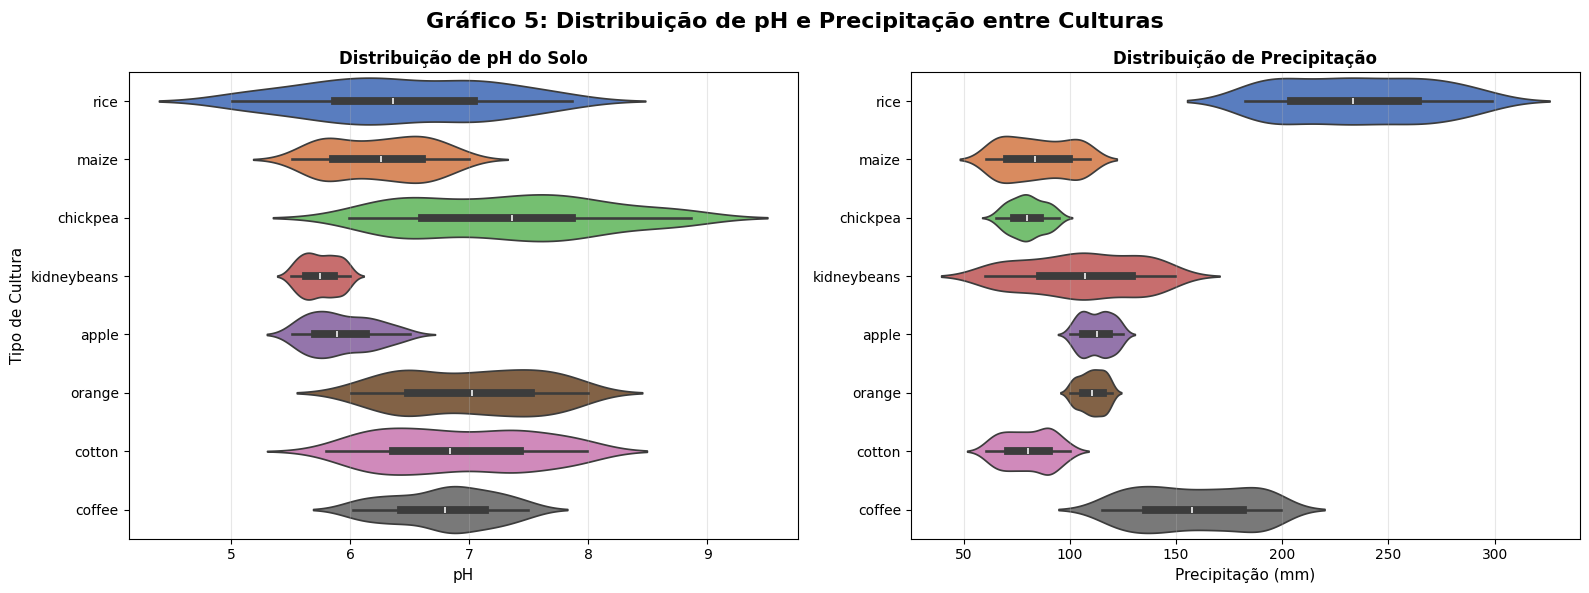


📊 ACHADOS DO GRÁFICO 5:
- pH: Arroz e milho toleram pH ligeiramente ácido (5.5-7.0)
- pH: Café prefere solos mais ácidos; grão de bico prefere pH neutro a alcalino
- PRECIPITAÇÃO: Arroz necessita de muita água (200-300mm)
- PRECIPITAÇÃO: Grão de bico e kidneybeans se adaptam a baixa precipitação (60-150mm)
- Variação de precipitação é um fator crítico na escolha da cultura


In [ ]:
# Gráfico 5: Violin plots de pH e Rainfall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gráfico 5: Distribuição de pH e Precipitação entre Culturas',
             fontsize=16, fontweight='bold', y=0.98)

# Selecionar algumas culturas para melhor visualização
selected_crops = ['rice', 'maize', 'chickpea', 'kidneybeans', 'apple', 'orange', 'cotton', 'coffee']
df_selected = df[df['label'].isin(selected_crops)]

# pH
sns.violinplot(data=df_selected, y='label', x='ph', ax=axes[0], palette='muted', orient='h')
axes[0].set_title('Distribuição de pH do Solo', fontweight='bold', fontsize=12)
axes[0].set_xlabel('pH', fontsize=11)
axes[0].set_ylabel('Tipo de Cultura', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Precipitação
sns.violinplot(data=df_selected, y='label', x='rainfall', ax=axes[1], palette='muted', orient='h')
axes[1].set_title('Distribuição de Precipitação', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Precipitação (mm)', fontsize=11)
axes[1].set_ylabel('', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n📊 ACHADOS DO GRÁFICO 5:')
print('- pH: Arroz e milho toleram pH ligeiramente ácido (5.5-7.0)')
print('- pH: Café prefere solos mais ácidos; grão de bico prefere pH neutro a alcalino')
print('- PRECIPITAÇÃO: Arroz necessita de muita água (200-300mm)')
print('- PRECIPITAÇÃO: Grão de bico e kidneybeans se adaptam a baixa precipitação (60-150mm)')
print('- Variação de precipitação é um fator crítico na escolha da cultura')

📕 Análise estatística por grupo de culturas

In [ ]:
# Estatísticas agrupadas por cultura
print('\n=== ESTATÍSTICAS MÉDIAS POR CULTURA ===')
crop_stats = df.groupby('label')[variables].mean().round(2)
crop_stats

# Identificar culturas com maior e menor demanda de cada nutriente
print('\n=== CULTURAS COM MAIOR DEMANDA POR NUTRIENTE ===')
for nutrient in ['N', 'P', 'K']:
    crop_means = df.groupby('label')[nutrient].mean().sort_values(ascending=False)
    print(f'\n{nutrient} - Top 5:')
    print(crop_means.head())

print('\n=== CULTURAS COM MENOR DEMANDA POR NUTRIENTE ===')
for nutrient in ['N', 'P', 'K']:
    crop_means = df.groupby('label')[nutrient].mean().sort_values()
    print(f'\n{nutrient} - Bottom 5:')
    print(crop_means.head())


=== ESTATÍSTICAS MÉDIAS POR CULTURA ===

=== CULTURAS COM MAIOR DEMANDA POR NUTRIENTE ===

N - Top 5:
label
cotton        117.77
coffee        101.20
muskmelon     100.32
banana        100.23
watermelon     99.42
Name: N, dtype: float64

P - Top 5:
label
apple       134.22
grapes      132.53
banana       82.01
lentil       68.36
chickpea     67.79
Name: P, dtype: float64

K - Top 5:
label
grapes        200.11
apple         199.89
chickpea       79.92
watermelon     50.22
muskmelon      50.08
Name: K, dtype: float64

=== CULTURAS COM MENOR DEMANDA POR NUTRIENTE ===

N - Bottom 5:
label
lentil         18.77
pomegranate    18.87
orange         19.58
mango          20.07
pigeonpeas     20.73
Name: N, dtype: float64

P - Bottom 5:
label
orange         16.55
coconut        16.93
watermelon     17.00
muskmelon      17.72
pomegranate    18.75
Name: P, dtype: float64

K - Bottom 5:
label
orange       10.01
blackgram    19.24
lentil       19.41
cotton       19.56
maize        19.79
Name: K, dty

## 4. Conclusões da Análise Exploratória

### Principais Descobertas:

**1. Qualidade dos Dados:**
- Dataset completo com 2.200 observações e sem valores ausentes
- Distribuição balanceada entre 22 tipos de culturas (100 amostras cada)
- Todas as variáveis apresentam boa variabilidade

**2. Padrões Identificados:**
- **Nutrientes (NPK)**: Cada cultura possui requisitos únicos de nutrientes:
  - Arroz, algodão e banana demandam alto nitrogênio
  - Maçã e uvas necessitam de muito potássio
  - Leguminosas (grão de bico, lentilha) requerem níveis moderados de NPK

- **Condições Climáticas**: Clusters bem definidos:
  - Arroz: Alta umidade e precipitação
  - Grão de bico, mothbeans: Baixa umidade, clima seco
  - Frutas tropicais: Alta umidade e temperatura

- **pH do Solo**: Variação significativa entre culturas
  - Coffee prefere solos ácidos (pH 5-6)
  - Leguminosas preferem pH neutro (6-7)

**3. Implicações para Modelagem Preditiva:**
- Baixa correlação entre variáveis: ausência de multicolinearidade
- Clusters bem definidos no espaço PCA: boa separabilidade
- Todas as 7 variáveis são relevantes para classificação
- Dados adequados para múltiplos algoritmos de ML (Decision Trees, Random Forest, SVM, KNN, Neural Networks)

**4. Recomendações:**
- Não é necessário remover outliers (variabilidade natural das culturas)
- Recomenda-se normalização/padronização para algoritmos baseados em distância
- Feature engineering pode incluir razões NPK e interações entre variáveis climáticas
- Validação cruzada estratificada deve ser usada devido ao balanceamento das classes

# 🌻 Perfil Ideal de Solo/Clima

#### Gráfico

- `cinza`: Perfil Ideal Geral
- `Barras coloridas`: (Arroz, Manga, Café) serão as Receitas Especiais.

<Figure size 1800x1000 with 0 Axes>

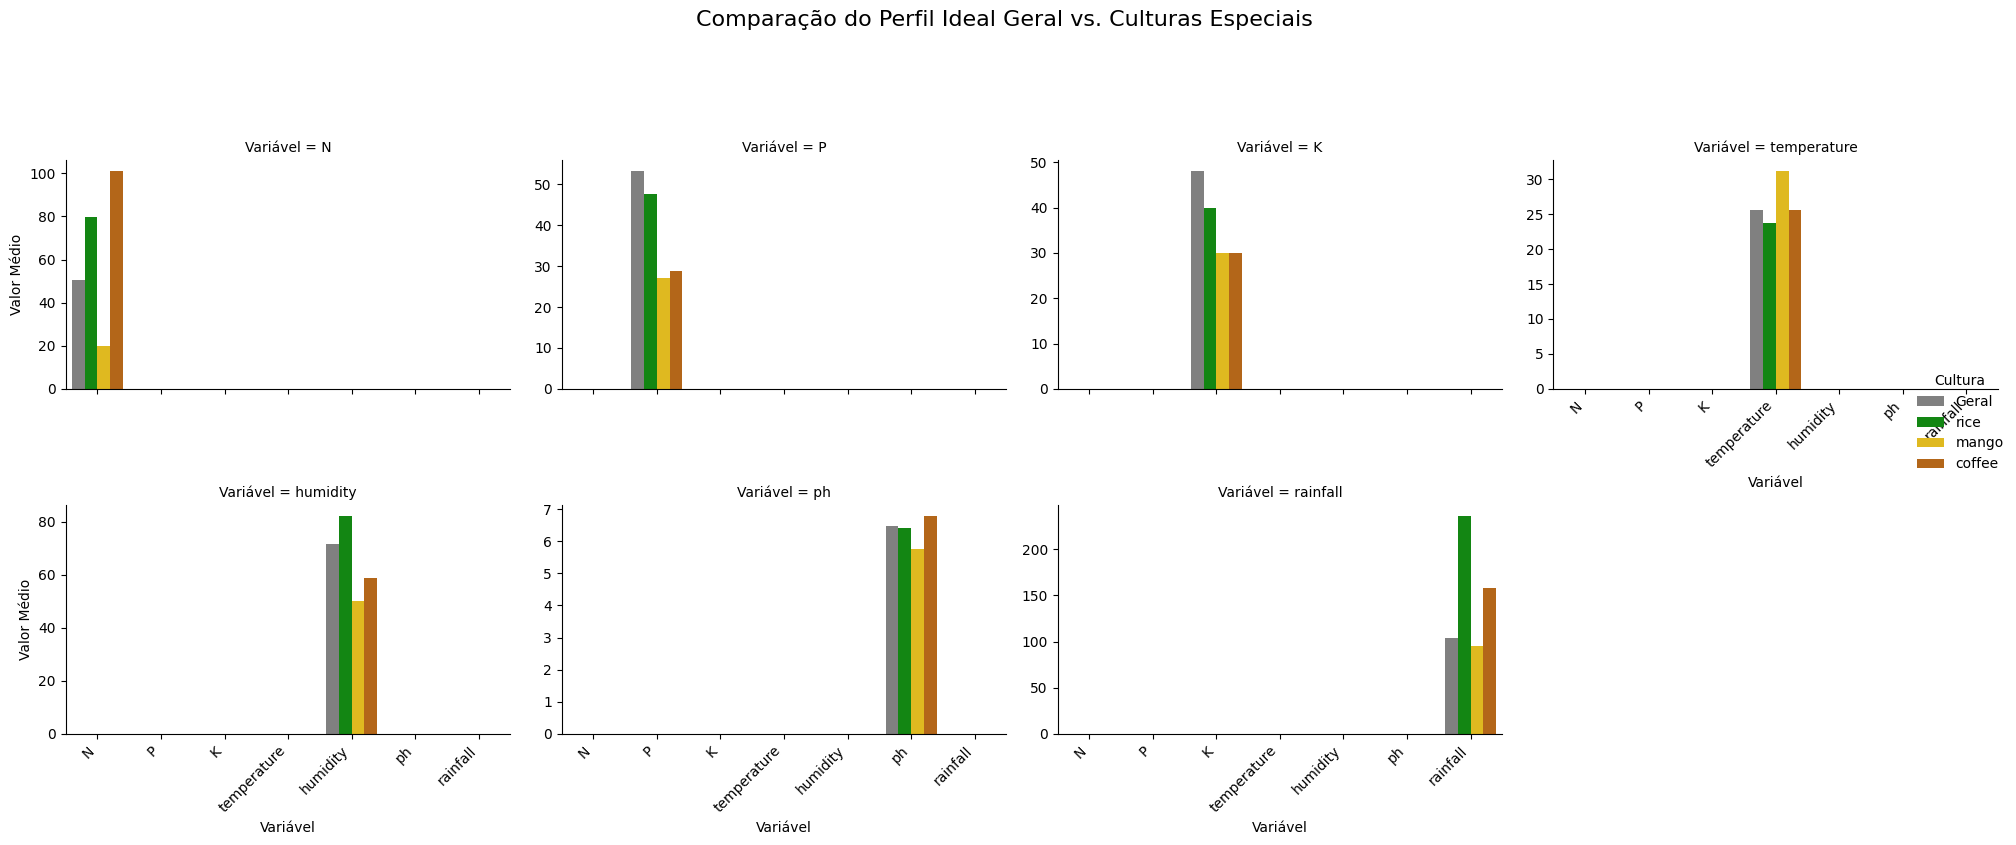

In [ ]:
# --- 1. CÁLCULO DOS PERFIS ---

# 1.1 Perfil Ideal Geral (Média de TODAS as culturas)
perfil_ideal_geral = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].mean()
perfil_ideal_geral.name = 'Geral'

# 1.2 Perfis Individuais (Receitas Especiais)
perfis_por_cultura = df.groupby('label')[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].mean()
culturas_para_analise = ['rice', 'mango', 'coffee']
perfis_especiais = perfis_por_cultura.loc[culturas_para_analise]

# --- 2. PREPARO DO DATAFRAME PARA PLOTAGEM ---

# Combina o perfil geral com os perfis especiais em um único DataFrame
df_comparacao = pd.concat([perfil_ideal_geral.to_frame().T, perfis_especiais])

# Converte o DataFrame para o formato "longo" (melt) necessário para o Seaborn
df_plot = df_comparacao.reset_index().rename(columns={'index': 'Cultura'}).melt(
    id_vars='Cultura',
    var_name='Variável',
    value_name='Valor Médio'
)

# Filtra as variáveis para focar apenas nas 3 principais (NPK) + 3 de clima (Temperatura, Chuva, pH)
variaveis_focais = ['N', 'P', 'K', 'temperature', 'rainfall', 'ph', 'humidity']
df_plot_focal = df_plot[df_plot['Variável'].isin(variaveis_focais)]

# --- 3. GERAÇÃO DO GRÁFICO ---

plt.figure(figsize=(18, 10))

# Cria o gráfico de barras agrupadas usando Facet Grid do Seaborn
g = sns.catplot(
    data=df_plot_focal,
    x='Variável',
    y='Valor Médio',
    hue='Cultura',
    kind='bar',
    palette=['#808080', '#009900', '#FFCC00', '#CC6600'], # Cores para destacar
    col='Variável',
    col_wrap=4,
    sharey=False, # Mantenha escalas Y diferentes para melhor visualização
    height=4,
    aspect=1.2
)

# Ajusta títulos e rótulos
g.set_axis_labels("Variável", "Valor Médio")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Comparação do Perfil Ideal Geral vs. Culturas Especiais', fontsize=16, y=1.05)

# Rotaciona os rótulos do eixo X (Variável) para melhor leitura
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 🔎 Análise do "Perfil Ideal" de Solo/Clima

1. ## Arroz (Rice)

#### O **arroz** se destaca principalmente por suas necessidades climáticas extremas.

- **Precipitação e Umidade**: O arroz exige altíssima precipitação (chuva) e alta umidade (os valores são muito superiores à média geral). Este é o fator limitante mais importante, indicando que o arroz só prospera em ambientes alagados ou com irrigação abundante.

- **Nutrientes (NPK)**: Os requisitos de Nitrogênio (N) e Potássio (K) do arroz estão ligeiramente acima da média geral, mas suas necessidades de Fósforo (P) são comparáveis.

- **Conclusão:** É uma cultura que prioriza o recurso hídrico sobre a fertilidade, adaptando-se a solos que apenas se desviam moderadamente da média em termos de NPK, mas que garantem água em excesso.

2. ## Manga (Mango)

#### A **manga** apresenta um perfil que se afasta do ideal geral em termos de baixa necessidade de nutrientes e alta tolerância a temperaturas.

- **Temperatura**: A manga prefere mais calor do que o Perfil Ideal Geral. Seus requisitos de temperatura são notavelmente elevados, caracterizando-a como uma fruta tropical de clima quente.

- **Fósforo** (P): A manga demanda menos Fósforo (P) e menos Nitrogênio (N) do que a média. Isso a torna adequada para solos que não são tão ricos em nutrientes (baixa manutenção em termos de fertilização).

- **pH do Solo**: O pH do solo que a manga prefere é ligeiramente mais ácido do que o pH neutro do Perfil Ideal Geral.

- **Conclusão**: É uma cultura que busca climas mais quentes e consegue produzir bem em solos mais pobres em nutrientes, desde que o ambiente seja quente.

3. ## Café (Coffee)

#### O **café** mostra uma combinação peculiar de alta exigência de fertilidade e tolerância a umidade do ar mais baixa.

- **Nitrogênio** (N): O café demonstra uma demanda por alto Nitrogênio, com valores significativamente acima da média geral, indicando que é uma cultura que esgota rapidamente a reserva de N do solo.

- **Precipitação e Umidade**: Embora necessite de uma precipitação acima da média (muita água no solo), sua umidade do ar preferencial é abaixo da média geral.

- **pH do Solo**: O café tolera um pH do solo que tende a ser ligeiramente mais alcalino (menos ácido) do que muitas outras culturas, embora o desvio em relação ao perfil geral seja pequeno.

- **Conclusão**: É uma cultura muito exigente em fertilização nitrogenada e, embora precise de muita água para se desenvolver, se adapta a ambientes onde a umidade do ar não é tão extrema quanto a do arroz.

# 🤖 Machine Learning (Pré-processamento de dados)

O processo de Pré-processamento para o projeto envolve quatro etapas principais:

- Separação de Dados: Definir as Variáveis de Entrada (X) e a Variável Alvo (y).

- Transformação da Variável Alvo: Converter os nomes das culturas (texto) em números.

- Escalonamento/Padronização: Normalizar as variáveis numéricas de entrada (N, P, K, etc.)

- Divisão de dados para treino e para teste.




In [ ]:
# 1 SEPARAÇÃO X e Y
X = df[feature_cols]
y = df['label']

# 2 TRANSFORMAÇÃO DA VARIÁVEL ALVO (Label Encoding)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("\nVariável Alvo (y) transformada para números.")

# 3 ESCALONAMENTO DAS FEATURES (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4 DIVISÃO DOS DADOS (Treino e Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n--- DADOS PRONTOS PARA ML ---")
print(f"Treino (X, y): {X_train.shape}, {y_train.shape}")
print(f"Teste (X, y): {X_test.shape}, {y_test.shape}")
# print("\nAgora podemos prosseguir com a implementação dos 5 modelos!")


Variável Alvo (y) transformada para números.

--- DADOS PRONTOS PARA ML ---
Treino (X, y): (1760, 7), (1760,)
Teste (X, y): (440, 7), (440,)


# 🤖 Machine Learning (Implementação dos Modelos)


In [ ]:
# --- 1. Importa os modelos de Machine Learning ---

# Importa os modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Importa as métricas de avaliação
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [ ]:
# --- 2. Treinamento e Avaliação ---

# Lista para armazenar os resultados de performance
resultados = []

# Dicionário de modelos a serem testados
modelos = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine (SVM)': SVC(random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5)
}

print("=== TREINAMENTO E PREVISÃO ===")

for nome, modelo in modelos.items():
    print(f"Treinando: {nome}...")

    # TREINAR o modelo (Aprender com os dados de treino)
    modelo.fit(X_train, y_train)

    # PREVER com os dados de teste (A 'Prova Final')
    y_pred = modelo.predict(X_test)

    # --- AVALIAÇÃO DO MODELO ---

    # Métrica 1: Acurácia
    acuracia = accuracy_score(y_test, y_pred)

    # Métrica 2: F1-Score (Usamos 'weighted' por ser multiclasse)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Métrica 3: Matriz de Confusão (Não exibimos aqui, mas calculamos para o melhor)

    # Armazena os resultados
    resultados.append({
        'Modelo': nome,
        'Acurácia': acuracia,
        'F1-Score': f1
    })

print("\nTreinamento concluído para todos os modelos.")

=== TREINAMENTO E PREVISÃO ===
Treinando: Logistic Regression...
Treinando: Decision Tree...
Treinando: Random Forest...
Treinando: Support Vector Machine (SVM)...
Treinando: K-Nearest Neighbors (KNN)...

Treinamento concluído para todos os modelos.


In [ ]:
# --- 3. Comparação dos Resultados ---

df_resultados = pd.DataFrame(resultados)

# Ordena pelo F1-Score para encontrar o melhor modelo
df_resultados_ordenado = df_resultados.sort_values(by='F1-Score', ascending=False)

print("\n=== RANKING DE PERFORMANCE DOS MODELOS ===")
print(df_resultados_ordenado.round(4))


=== RANKING DE PERFORMANCE DOS MODELOS ===
                         Modelo  Acurácia  F1-Score
2                 Random Forest    0.9955    0.9955
3  Support Vector Machine (SVM)    0.9841    0.9840
1                 Decision Tree    0.9795    0.9794
4     K-Nearest Neighbors (KNN)    0.9795    0.9793
0           Logistic Regression    0.9727    0.9725


# 🏆 Análise do Ranking de Performance

#### O `modelo lm` que obteve maior sucesso em sua performance foi o 🌳 `Random Forest`


É o melhor modelo. Atingiu uma performance de quase $99.6\%$ de acerto. Isso significa que, a cada 100 previsões sobre qual cultura plantar, o modelo erra menos de uma vez (em média).

Por fim iremos analisar a
 🖼️ **Matriz de Confusão (Random Forest)**

A Matriz de Confusão irá disponibilizar um gráfico para mostrar onde exatamente o modelo cometeu os poucos erros ($0.45\%$ de erro).

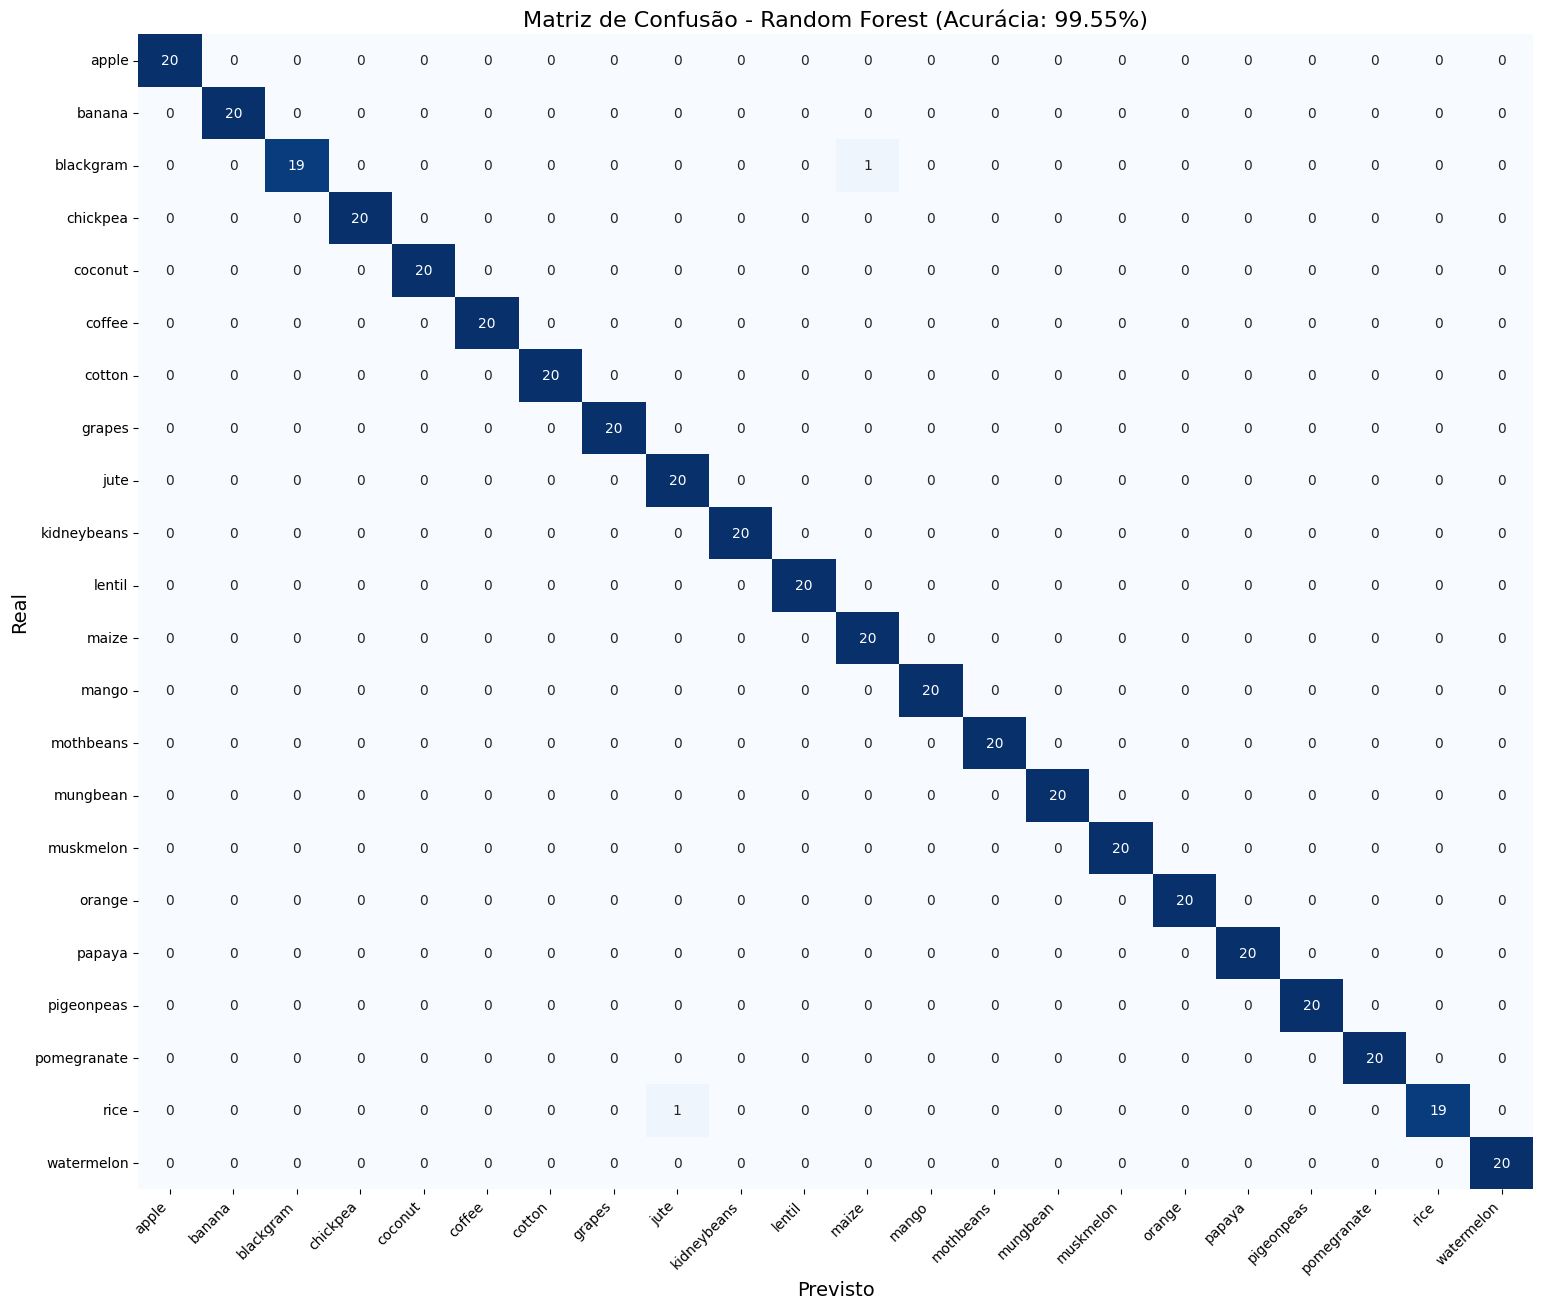

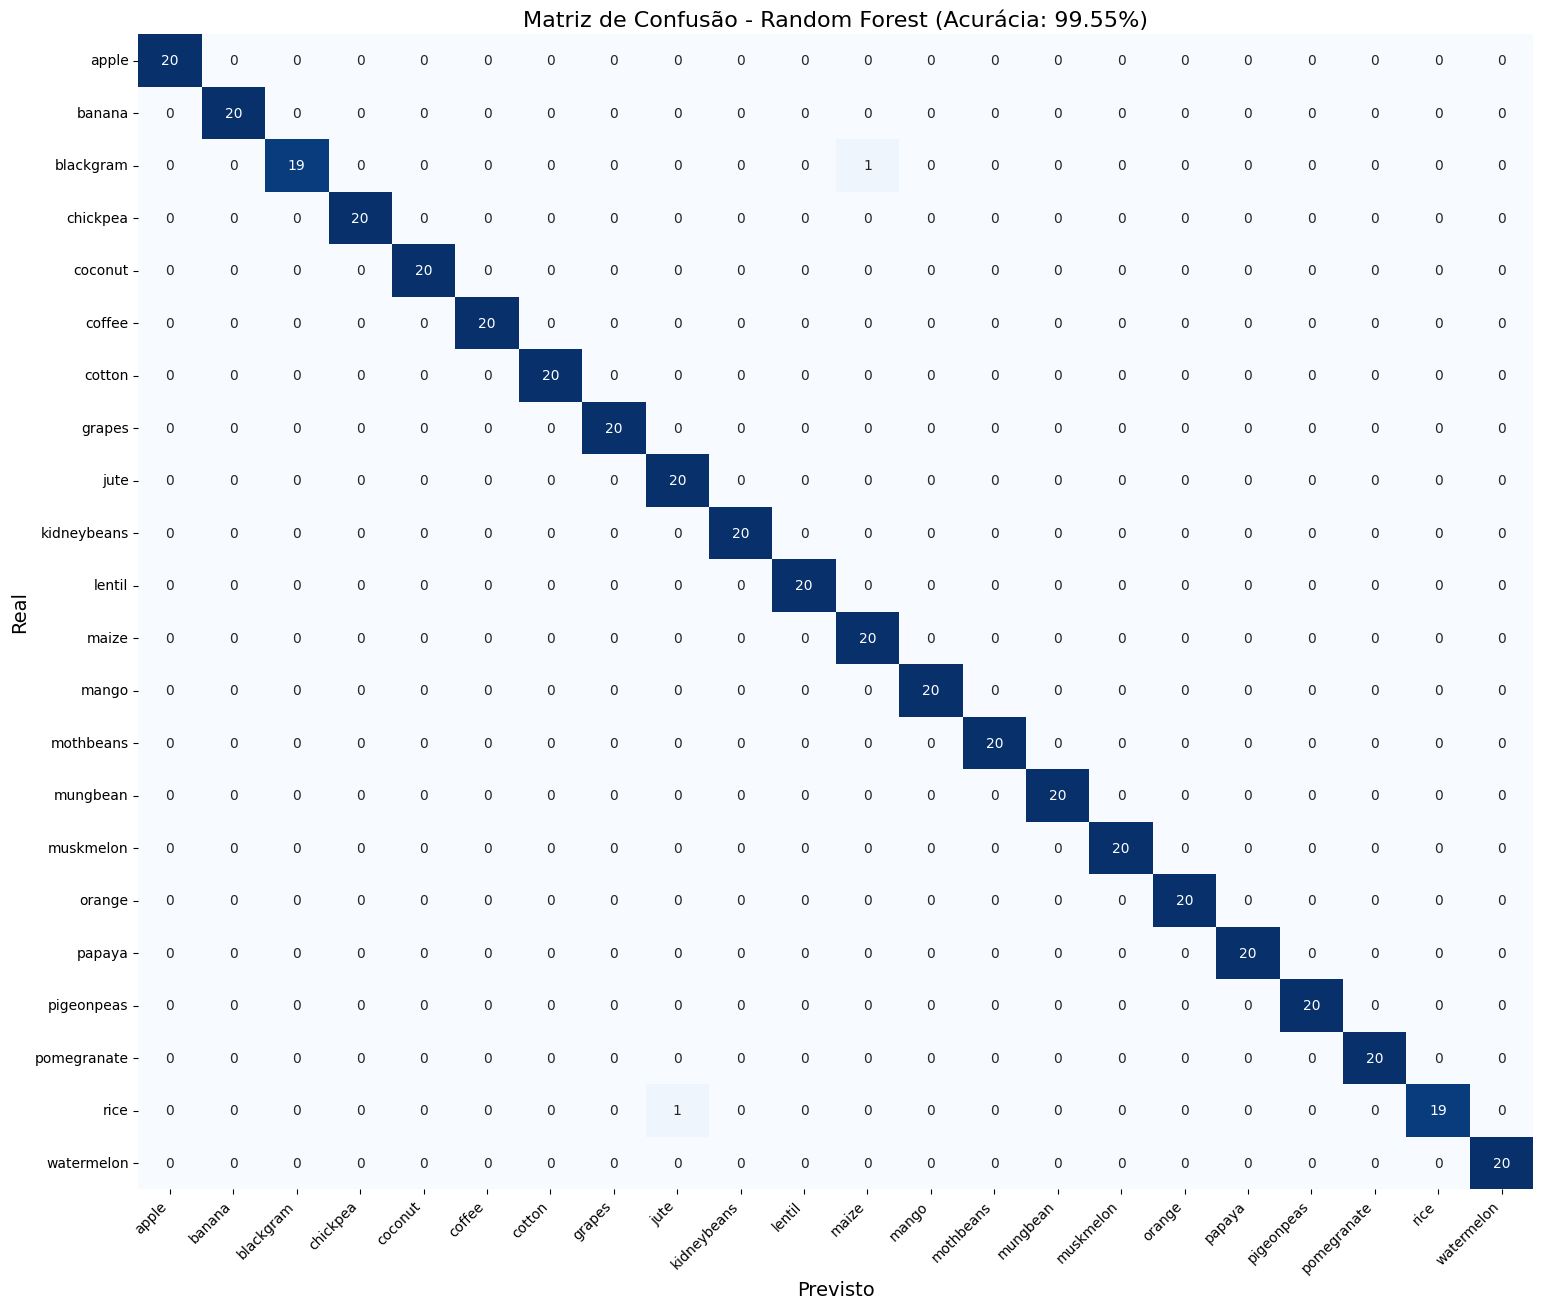

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Identificar o Melhor Modelo e Prever
# O modelo Random Forest foi o vencedor do ranking
melhor_modelo = modelos['Random Forest']

# Previsões nos dados de teste
y_pred_melhor = melhor_modelo.predict(X_test)

# 2. Gerar a Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred_melhor)

# 3. Mapeamento dos Rótulos (para que o gráfico mostre nomes em vez de números)
# Reverter a codificação para obter os nomes das culturas
labels_nomes = label_encoder.classes_

# 4. Plotagem Visual da Matriz
plt.figure(figsize=(18, 15))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_nomes,
    yticklabels=labels_nomes,
    cbar=False  # Cbar=False para focar nos números
)
plt.title('Matriz de Confusão - Random Forest (Acurácia: 99.55%)', fontsize=16)
plt.xlabel('Previsto', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# O valor final da sua matriz de confusão.import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Identificar o Melhor Modelo e Prever
# O modelo Random Forest foi o vencedor do ranking
melhor_modelo = modelos['Random Forest']

# Previsões nos dados de teste
y_pred_melhor = melhor_modelo.predict(X_test)

# 2. Gerar a Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred_melhor)

# 3. Mapeamento dos Rótulos (para que o gráfico mostre nomes em vez de números)
# Reverter a codificação para obter os nomes das culturas
labels_nomes = label_encoder.classes_

# 4. Plotagem Visual da Matriz
plt.figure(figsize=(18, 15))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_nomes,
    yticklabels=labels_nomes,
    cbar=False  # Cbar=False para focar nos números
)
plt.title('Matriz de Confusão - Random Forest (Acurácia: 99.55%)', fontsize=16)
plt.xlabel('Previsto', fontsize=14)
plt.ylabel('Real', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# O valor final da sua matriz de confusão.

# 📝 Redação Final do Relatório (Conclusões)

### 1. Pontos Fortes do Trabalho e do Dataset
**Alta Qualidade de Dados**: O dataset demonstrou ser de excelente qualidade, sendo completo (2.200 observações) e isento de valores ausentes, o que eliminou a necessidade de limpeza intensiva.

**Balanceamento Ideal**: O conjunto de dados é perfeitamente balanceado (100 amostras por cultura), garantindo que os modelos de Machine Learning aprendessem de forma equitativa sobre todas as classes.

**Performance Excepcional**: A combinação de alta qualidade de dados com variáveis bem separáveis resultou em uma performance de classificação notavelmente alta. O modelo vencedor, `Random Forest`, alcançou um `F1-Score` de 0.9955.

**Insights Aplicáveis**: A análise de Perfil Ideal (Média Geral vs. Receitas Especiais) gerou insights claros e acionáveis sobre as preferências de nutrientes (ex: alta demanda de Nitrogênio para o Café) e condições climáticas (ex: demanda extrema de Precipitação para o Arroz).

### 2. Limitações do Modelo e Próximos Passos
**Erros Residuais e Limitações do Modelo Vencedor**: Performance Praticamente Perfeita, Mas Não Absoluta: Apesar do modelo Random Forest ter atingido um F1-Score de 0.9955, a Matriz de Confusão revela as únicas falhas: 1 amostra de 'rice' (arroz) foi erroneamente classificada como 'jute' (juta) e 1 amostra de 'blackgram' (feijão-mungo-preto) foi classificada incorretamente como 'maize' (milho).

**Generalização Geográfica**: A principal limitação é que o modelo foi treinado em um conjunto específico de dados de uma determinada região. Sua alta performance pode não se replicar em solos e climas dramaticamente diferentes dos observados.

**Limitação na Distinção de Leguminosas/Cereais**: A confusão entre blackgram e maize é particularmente notável, pois sugere que, para aquele ponto de dado específico, a combinação de NPK e condições climáticas do blackgram era estatisticamente mais similar ao perfil do Milho (que é um grande consumidor de Nitrogênio) do que ao seu próprio grupo. O erro demonstra que, apesar da altíssima acurácia, o modelo encontra ambiguidade na fronteira entre culturas com perfis de cultivo muito próximos.

**Recomendação de Implementação**: Para uso em produção, o modelo `Random Forest` é o mais recomendado. Sugere-se a coleta de variáveis adicionais (ex: topografia, presença de pragas) para tentar eliminar completamente os poucos erros restantes na Matriz de Confusão.